>>> Reading logs from: /kaggle/input/cv-project-phase-5-optimization-analysis
Generating Final Plots...
Plot saved to: 1_analysis_fixed.png


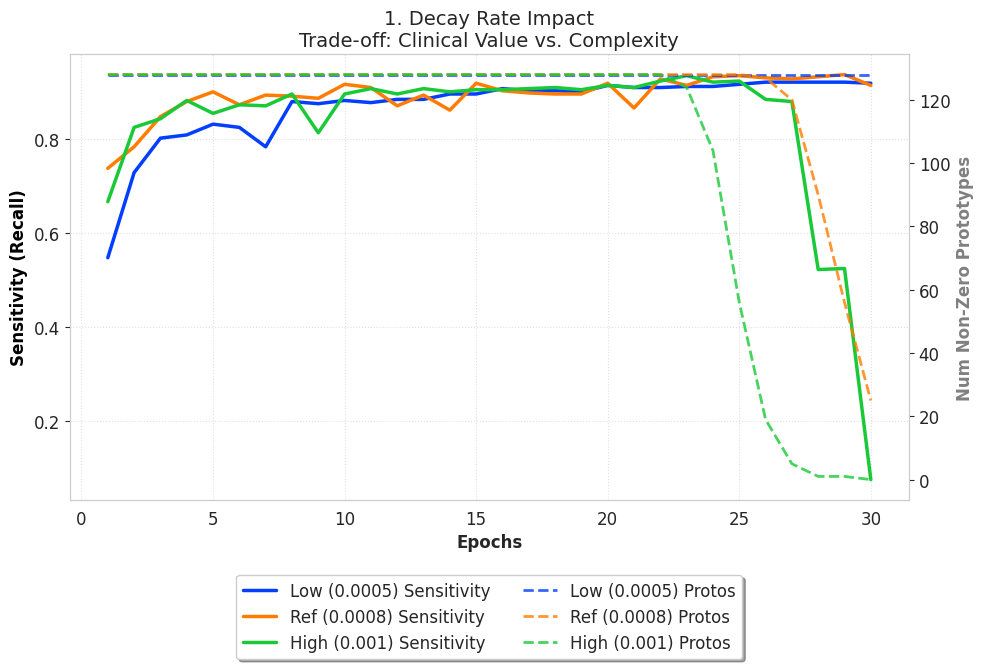

Plot saved to: 2_analysis_fixed.png


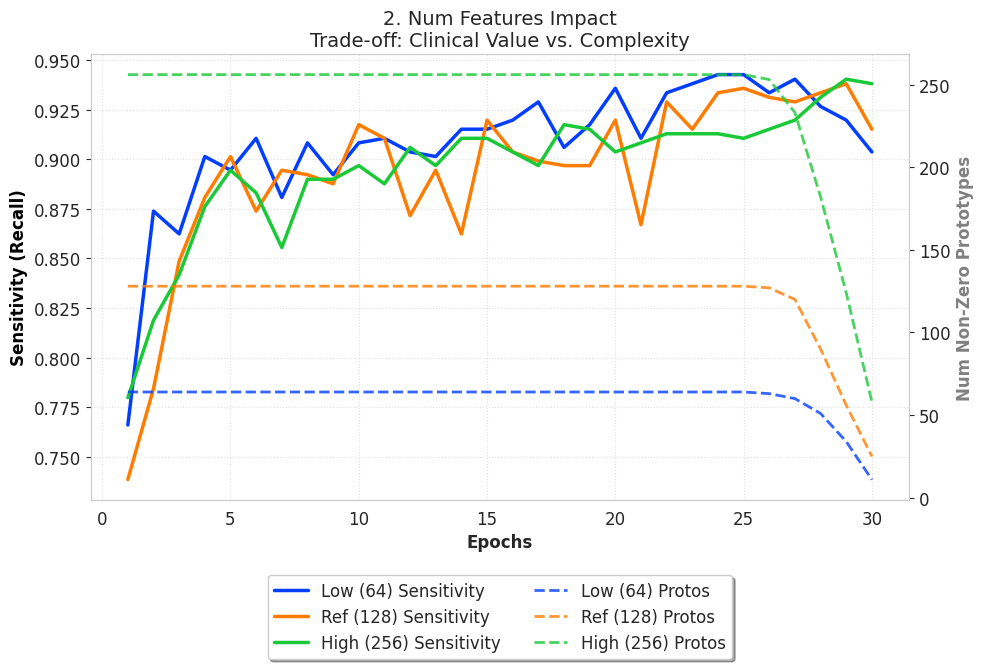

Plot saved to: 3_analysis_fixed.png


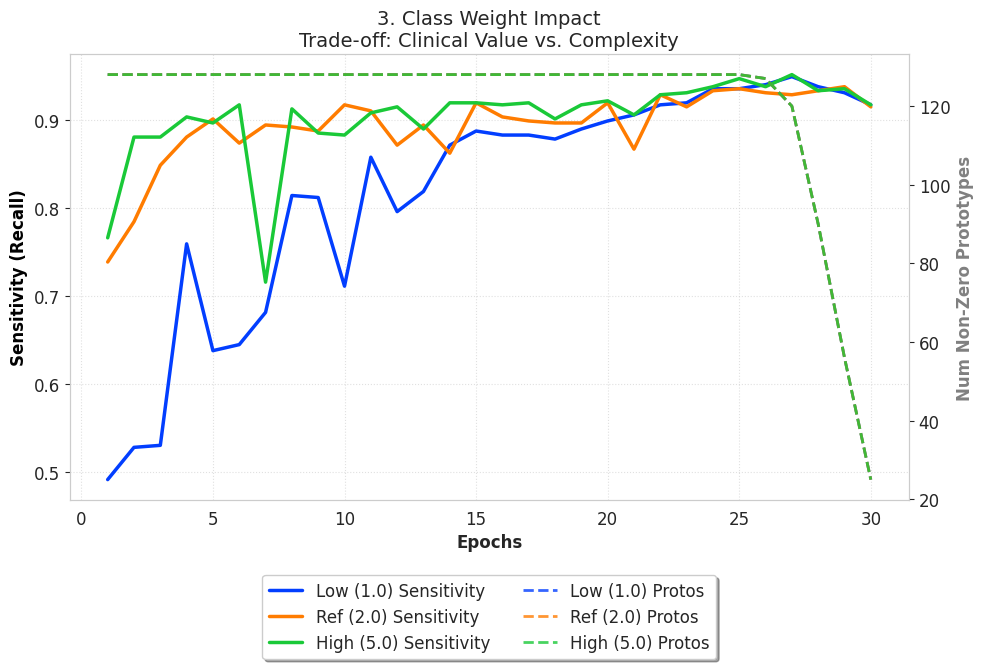

Plot saved to: 4_analysis_fixed.png


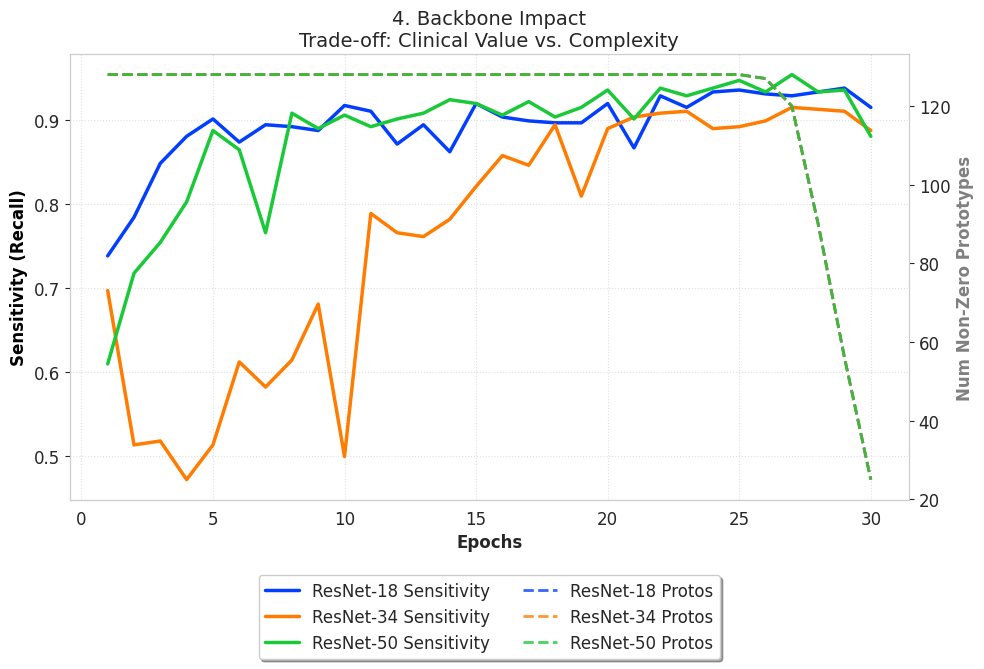

In [1]:
# =================================================================
# VISUALIZATION (FINAL FIX)
# =================================================================
# Objective: Visualize Sensitivity vs. Sparsity from Saved Output.
# Fixes:
# 1. Handles different column names ('num_nonz' vs 'num_nonzero_prototypes').
# 2. Moves legend to bottom to avoid overlap.
# 3. Corrects Dual-Axis scaling.
# =================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -----------------------------------------------------------------
# CONFIGURATION
# -----------------------------------------------------------------
NOTEBOOK_NAME = 'cv-project-phase-5-optimization-analysis'
base_dir = os.path.join('/kaggle/input', NOTEBOOK_NAME)

print(f">>> Reading logs from: {base_dir}")
# -----------------------------------------------------------------

# Set plot aesthetics
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 7)})

# Define the groups
studies = {
    '1. Decay Rate Impact': {
        'Low (0.0005)': os.path.join(base_dir, 'exp_decay_low'),
        'Ref (0.0008)': os.path.join(base_dir, 'experiment_feasible_optimized'),
        'High (0.001)': os.path.join(base_dir, 'exp_decay_high')
    },
    '2. Num Features Impact': {
        'Low (64)': os.path.join(base_dir, 'exp_feat_low'),
        'Ref (128)': os.path.join(base_dir, 'experiment_feasible_optimized'),
        'High (256)': os.path.join(base_dir, 'exp_feat_high')
    },
    '3. Class Weight Impact': {
        'Low (1.0)': os.path.join(base_dir, 'exp_wclass_low'),
        'Ref (2.0)': os.path.join(base_dir, 'experiment_feasible_optimized'),
        'High (5.0)': os.path.join(base_dir, 'exp_wclass_high')
    },
    '4. Backbone Impact': {
        'ResNet-18': os.path.join(base_dir, 'experiment_feasible_optimized'),
        'ResNet-34': os.path.join(base_dir, 'exp_net_resnet34'),
        'ResNet-50': os.path.join(base_dir, 'exp_net_resnet50')
    }
}

# --- Helper to find correct column names ---
def get_column_name(df, possible_names):
    for name in possible_names:
        if name in df.columns:
            return name
    return None

# --- Function to generate plots ---
def plot_study_results(study_name, experiments):
    fig, ax1 = plt.subplots(figsize=(10, 7))
    ax2 = ax1.twinx() # Create the second axis
    
    colors = sns.color_palette("bright", len(experiments))
    valid_data = False
    
    for i, (label, path) in enumerate(experiments.items()):
        log_path = os.path.join(path, 'log_epoch_overview.csv')
        
        if os.path.exists(log_path):
            try:
                df = pd.read_csv(log_path)
                valid_data = True
                
                # 1. Handle Sensitivity/Accuracy Column
                metric_col = get_column_name(df, ['sensitivity', 'test_acc'])
                metric_label = 'Sensitivity' if metric_col == 'sensitivity' else 'Accuracy'
                
                # 2. Handle Prototypes Column 
                proto_col = get_column_name(df, ['num_nonz', 'num_nonzero_prototypes'])
                
                if metric_col and proto_col:
                    # Plot Metric (Solid Line) - Left Axis
                    ax1.plot(df['epoch'], df[metric_col], label=f'{label} {metric_label}', 
                             color=colors[i], linestyle='-', linewidth=2.5)
                    
                    # Plot Prototypes (Dashed Line) - Right Axis
                    ax2.plot(df['epoch'], df[proto_col], label=f'{label} Protos', 
                             color=colors[i], linestyle='--', alpha=0.8, linewidth=2)
                else:
                    print(f"Skipping {label}: Required columns not found in CSV.")
                    print(f"Columns found: {df.columns.tolist()}")

            except Exception as e:
                print(f"Error reading log for {label}: {e}")
        else:
            print(f"Warning: Log not found for {label} at {log_path}")

    if valid_data:
        # Dynamic Labeling
        y_label_1 = 'Sensitivity (Recall)' 
        y_label_2 = 'Num Non-Zero Prototypes'
        
        # Axis 1 Settings (Left)
        ax1.set_xlabel('Epochs', fontweight='bold')
        ax1.set_ylabel(y_label_1, fontweight='bold', color='black')
        ax1.grid(True, linestyle=':', alpha=0.6)
        
        # Axis 2 Settings (Right)
        ax2.set_ylabel(y_label_2, fontweight='bold', color='gray')
        ax2.grid(False) # Turn off grid for second axis to avoid clutter
        
        plt.title(f'{study_name}\nTrade-off: Clinical Value vs. Complexity', fontsize=14)
        
        # LEGEND FIX: Place legend BELOW the plot
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, 
                   loc='upper center', bbox_to_anchor=(0.5, -0.15),
                   fancybox=True, shadow=True, ncol=2)
        
        plt.tight_layout()
        
        # Save and Show
        save_path = f'{study_name.split(".")[0].strip()}_analysis_fixed.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
        plt.show()
    else:
        print(f"No valid data found for {study_name}")

# --- Execution ---
print("Generating Final Plots...")
for study_name, exps in studies.items():
    plot_study_results(study_name, exps)

In [2]:
# =================================================================
# SUMMARY TABLE GENERATION
# =================================================================
# Objective: Extract numerical results for the final report table.
# =================================================================

print("\nGenerating Summary CSV Table...")
summary_data = []

for study, exps in studies.items():
    for name, path in exps.items():
        log_path = os.path.join(path, 'log_epoch_overview.csv')
        if os.path.exists(log_path):
            df = pd.read_csv(log_path)
            
            # Identify the best epoch based on Sensitivity (or Accuracy)
            sort_metric = 'sensitivity' if 'sensitivity' in df.columns else 'test_acc'
            best_epoch = df.loc[df[sort_metric].idxmax()]
            
            summary_data.append({
                'Study Group': study,
                'Configuration': name,
                'Best Sensitivity': f"{best_epoch.get('sensitivity', 0):.4f}",
                'Best Accuracy': f"{best_epoch['test_acc']:.4f}",
                'Prototypes (Best)': int(best_epoch['num_nonzero_prototypes']),
                'Prototypes (Final)': int(df.iloc[-1]['num_nonzero_prototypes'])
            })

if summary_data:
    df_sum = pd.DataFrame(summary_data)
    
    # Reorder for clarity
    cols = ['Study Group', 'Configuration', 'Best Sensitivity', 'Best Accuracy', 'Prototypes (Best)', 'Prototypes (Final)']
    df_sum = df_sum[cols]
    
    # Save and Display
    df_sum.to_csv('/kaggle/working/phase5_final_results.csv', index=False)
    print("Table saved to: /kaggle/working/phase5_final_results.csv")
    display(df_sum)
else:
    print("No data found to generate table.")


Generating Summary CSV Table...
Table saved to: /kaggle/working/phase5_final_results.csv


,Study Group,Configuration,Best Sensitivity,Best Accuracy,Prototypes (Best),Prototypes (Final)
0,1. Decay Rate Impact,Low (0.0005),0.9220,0.9220,128,128
1,1. Decay Rate Impact,Ref (0.0008),0.9381,0.9381,56,25
2,1. Decay Rate Impact,High (0.001),0.9358,0.9358,124,0
3,2. Num Features Impact,Low (64),0.9427,0.9427,64,11
4,2. Num Features Impact,Ref (128),0.9381,0.9381,56,25
5,2. Num Features Impact,High (256),0.9404,0.9404,124,58
6,3. Class Weight Impact,Low (1.0),0.9495,0.9495,120,25
7,3. Class Weight Impact,Ref (2.0),0.9381,0.9381,56,25
8,3. Class Weight Impact,High (5.0),0.9518,0.9518,120,25
9,4. Backbone Impact,ResNet-18,0.9381,0.9381,56,25


In [3]:
import torch
import pandas as pd
import os

# ---------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------
# Path to the final checkpoint of the optimized experiment
checkpoint_path = '/kaggle/input/cv-project-phase-5-optimization-analysis/experiment_feasible_optimized/checkpoints/net_epoch_30.pth'

# Class names (Ensure this matches the training order)
class_names = ['COVID-19', 'Normal', 'Viral Pneumonia']
# ---------------------------------------------------------

def analyze_prototype_weights(ckpt_path):
    """
    Loads the trained model and analyzes the classification layer weights
    to identify and rank the most influential prototypes.
    """
    if not os.path.exists(ckpt_path):
        print(f"Error: Checkpoint NOT found at: {ckpt_path}")
        return None

    print(f">>> Loading model from: {ckpt_path}")
    try:
        # Load checkpoint (map to CPU for safety)
        checkpoint = torch.load(ckpt_path, map_location='cpu')
    except Exception as e:
        print(f"Error loading torch file: {e}")
        return None
    
    # Extract model state dictionary
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    else:
        state_dict = checkpoint
        
    # Locate classification weights
    class_weights = None
    for key in state_dict.keys():
        if '_classification.weight' in key:
            class_weights = state_dict[key]
            break
            
    if class_weights is None:
        print("Could not find '_classification.weight' in state_dict.")
        return None

    num_classes, num_prototypes = class_weights.shape
    print(f"Model Structure Loaded: {num_classes} Classes, {num_prototypes} Total Prototype Slots")
    
    # Pruning Threshold: Weights below this are considered inactive
    threshold = 1e-3
    
    active_prototypes = []
    
    # --- Data Collection Phase ---
    for i in range(num_prototypes):
        # Get weights connecting prototype 'i' to all classes
        weights_for_proto = class_weights[:, i]
        
        # Identify the dominant class for this prototype
        max_weight, class_idx = torch.max(weights_for_proto, dim=0)
        
        # Filter dead prototypes
        if max_weight > threshold:
            active_prototypes.append({
                'Proto ID': i,
                'Max Weight': max_weight.item(),
                'Class Name': class_names[class_idx.item()],
                'Class Index': class_idx.item()
            })

    # Create DataFrame
    df = pd.DataFrame(active_prototypes)
    print(f"Total Active Prototypes Found: {len(df)}")
    print("=" * 60)

    # --- View 1: Global Ranking (Sorted by Importance) ---
    print("\nVIEW 1: GLOBAL RANKING (Sorted by Weight)")
    print(f"{'Proto ID':<10} | {'Max Weight':<12} | {'Associated Class':<20}")
    print("-" * 50)
    
    # Sort by Weight Descending
    df_global = df.sort_values(by='Max Weight', ascending=False)
    for _, row in df_global.iterrows():
        print(f"{int(row['Proto ID']):<10} | {row['Max Weight']:.4f}       | {row['Class Name']}")

    # --- View 2: Class-wise Ranking (Grouped by Class) ---
    print("\n\nVIEW 2: CLASS-WISE BREAKDOWN (Sorted by Class & Weight)")
    print(f"{'Proto ID':<10} | {'Max Weight':<12} | {'Associated Class':<20}")
    print("-" * 50)
    
    # Sort by Class Name then Weight Descending
    df_class = df.sort_values(by=['Class Name', 'Max Weight'], ascending=[True, False])
    for _, row in df_class.iterrows():
        print(f"{int(row['Proto ID']):<10} | {row['Max Weight']:.4f}       | {row['Class Name']}")
        
    return df

# Execute Analysis
df_results = analyze_prototype_weights(checkpoint_path)

>>> Loading model from: /kaggle/input/cv-project-phase-5-optimization-analysis/experiment_feasible_optimized/checkpoints/net_epoch_30.pth
Model Structure Loaded: 3 Classes, 128 Total Prototype Slots
Total Active Prototypes Found: 25

VIEW 1: GLOBAL RANKING (Sorted by Weight)
Proto ID   | Max Weight   | Associated Class    
--------------------------------------------------
85         | 0.2569       | Normal
122        | 0.1501       | Normal
127        | 0.1086       | Viral Pneumonia
46         | 0.0933       | Viral Pneumonia
41         | 0.0925       | COVID-19
6          | 0.0825       | Normal
126        | 0.0798       | Normal
75         | 0.0737       | Normal
117        | 0.0720       | COVID-19
115        | 0.0698       | COVID-19
114        | 0.0582       | Viral Pneumonia
104        | 0.0460       | COVID-19
14         | 0.0353       | Normal
80         | 0.0301       | COVID-19
62         | 0.0271       | COVID-19
73         | 0.0235       | Viral Pneumonia
17         | 0.0